In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchcodec.decoders import VideoDecoder
from transformers import AutoModelForVideoClassification, AutoVideoProcessor

/home/isabelle/miniconda3/envs/tutorial_udf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

hf_repo = "facebook/vjepa2-vitl-fpc16-256-ssv2"

processor = AutoVideoProcessor.from_pretrained(hf_repo)

model = AutoModelForVideoClassification.from_pretrained(
    hf_repo,
).to(device)

model.eval()

print("Device:", device)
print("Frames per clip:", model.config.frames_per_clip)
print("Number of labels:", model.config.num_labels)

Device: cuda
Frames per clip: 16
Number of labels: 174


In [3]:
video_url = "https://huggingface.co/datasets/nateraw/kinetics-mini/resolve/main/val/bowling/-WH-lxmGJVY_000005_000015.mp4"

vr = VideoDecoder(video_url)

print("Total frames in video:", len(vr))

frame_idx = np.linspace(
    0,
    len(vr) - 1,
    model.config.frames_per_clip,
    dtype=int,
)

video = vr.get_frames_at(indices=frame_idx).data

print("Raw video tensor:", video.shape)
print("Format: T x C x H x W")

Total frames in video: 150
Raw video tensor: torch.Size([16, 3, 270, 480])
Format: T x C x H x W


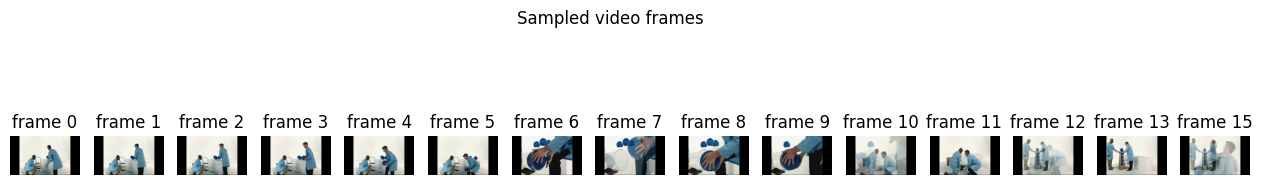

In [8]:
def show_video_frames(video, frame_indices=None, num_frames_to_show=8):
    """
    video shape: T x C x H x W
    """

    T = video.shape[0]

    if frame_indices is None:
        frame_indices = np.linspace(
            0,
            T - 1,
            num_frames_to_show,
            dtype=int,
        )

    fig, axes = plt.subplots(
        1,
        len(frame_indices),
        figsize=(16, 3),
    )

    for ax, idx in zip(axes, frame_indices):
        frame = video[idx]

        if isinstance(frame, torch.Tensor):
            frame = frame.cpu()

        frame = frame.permute(1, 2, 0).numpy()

        frame = np.clip(frame, 0, 255).astype(np.uint8)

        ax.imshow(frame)
        ax.set_title(f"frame {idx}")
        ax.axis("off")

    plt.suptitle("Sampled video frames")
    plt.show()


show_video_frames(video, num_frames_to_show=15)

In [5]:
inputs = processor(
    video,
    return_tensors="pt",
)

print(inputs.keys())

for key, value in inputs.items():
    print(key, value.shape, value.dtype)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

KeysView({'pixel_values_videos': tensor([[[[[ 2.0948,  2.0948,  2.0948,  ...,  2.0777,  2.0434,  2.0434],
           [ 2.0948,  2.0948,  2.0948,  ...,  2.0777,  2.0434,  2.0434],
           [ 2.0948,  2.0948,  2.0948,  ...,  2.0777,  2.0434,  2.0434],
           ...,
           [-1.6384, -0.9363, -0.3883,  ...,  1.1529,  1.1700,  1.2043],
           [-1.6727, -0.6623,  0.1768,  ...,  1.1529,  1.1700,  1.1872],
           [-1.7240, -0.7137,  0.1768,  ...,  1.1529,  1.1700,  1.1872]],

          [[ 2.1835,  2.1835,  2.1835,  ...,  2.2360,  2.2010,  2.2010],
           [ 2.1835,  2.1835,  2.1835,  ...,  2.2360,  2.2010,  2.2010],
           [ 2.1835,  2.1835,  2.1835,  ...,  2.2360,  2.2010,  2.2010],
           ...,
           [-1.3704, -0.6352, -0.0749,  ...,  1.2381,  1.2556,  1.2906],
           [-1.4405, -0.3901,  0.4678,  ...,  1.2381,  1.2556,  1.2731],
           [-1.5455, -0.4951,  0.4153,  ...,  1.2381,  1.2556,  1.2731]],

          [[ 2.1868,  2.1868,  2.1868,  ...,  2.2914,  

In [6]:
with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
    )

logits = outputs.logits

print("Logits shape:", logits.shape)
print("Meaning: batch_size x number_of_classes")

Logits shape: torch.Size([1, 174])
Meaning: batch_size x number_of_classes


In [7]:
probs = torch.softmax(logits, dim=-1)

top5 = probs.topk(5, dim=-1)

top5_probs = top5.values[0].cpu()
top5_indices = top5.indices[0].cpu()

print("Top 5 predicted class names:")

for idx, prob in zip(top5_indices, top5_probs):
    label = model.config.id2label[idx.item()]
    print(f"{label:40s} {prob.item():.4f}")

Top 5 predicted class names:
Stuffing [something] into [something]    0.2727
Piling [something] up                    0.1986
Putting [number of] [something] onto [something] 0.1180
Putting [something] into [something]     0.1141
Stacking [number of] [something]         0.0463


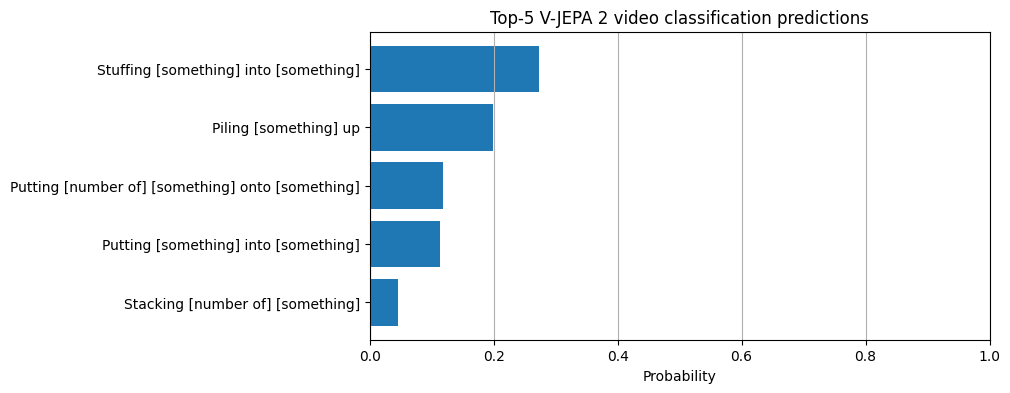

In [9]:
labels = [
    model.config.id2label[idx.item()]
    for idx in top5_indices
]

values = [
    prob.item()
    for prob in top5_probs
]

plt.figure(figsize=(8, 4))

plt.barh(labels[::-1], values[::-1])

plt.xlabel("Probability")
plt.title("Top-5 V-JEPA 2 video classification predictions")
plt.xlim(0, 1)
plt.grid(axis="x")

plt.show()

In [10]:
print("Number of hidden states:", len(outputs.hidden_states))

for i, hidden in enumerate(outputs.hidden_states):
    print(f"Layer {i:02d}:", hidden.shape)

Number of hidden states: 25
Layer 00: torch.Size([1, 2048, 1024])
Layer 01: torch.Size([1, 2048, 1024])
Layer 02: torch.Size([1, 2048, 1024])
Layer 03: torch.Size([1, 2048, 1024])
Layer 04: torch.Size([1, 2048, 1024])
Layer 05: torch.Size([1, 2048, 1024])
Layer 06: torch.Size([1, 2048, 1024])
Layer 07: torch.Size([1, 2048, 1024])
Layer 08: torch.Size([1, 2048, 1024])
Layer 09: torch.Size([1, 2048, 1024])
Layer 10: torch.Size([1, 2048, 1024])
Layer 11: torch.Size([1, 2048, 1024])
Layer 12: torch.Size([1, 2048, 1024])
Layer 13: torch.Size([1, 2048, 1024])
Layer 14: torch.Size([1, 2048, 1024])
Layer 15: torch.Size([1, 2048, 1024])
Layer 16: torch.Size([1, 2048, 1024])
Layer 17: torch.Size([1, 2048, 1024])
Layer 18: torch.Size([1, 2048, 1024])
Layer 19: torch.Size([1, 2048, 1024])
Layer 20: torch.Size([1, 2048, 1024])
Layer 21: torch.Size([1, 2048, 1024])
Layer 22: torch.Size([1, 2048, 1024])
Layer 23: torch.Size([1, 2048, 1024])
Layer 24: torch.Size([1, 2048, 1024])


In [11]:
last_hidden_state = outputs.hidden_states[-1]

print("Last hidden state:", last_hidden_state.shape)

video_embedding = last_hidden_state.mean(dim=1)

print("Global video embedding:", video_embedding.shape)

Last hidden state: torch.Size([1, 2048, 1024])
Global video embedding: torch.Size([1, 1024])


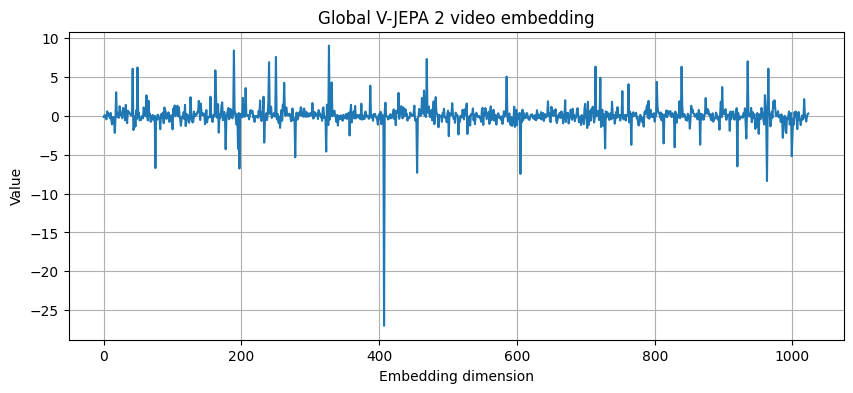

In [12]:
embedding = video_embedding[0].detach().cpu().numpy()

plt.figure(figsize=(10, 4))

plt.plot(embedding)

plt.title("Global V-JEPA 2 video embedding")
plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.grid(True)

plt.show()